# PD Model Training — Logistic Regression Scorecard

Train a Probability of Default (PD) model on feature-selected Lending Club data.

**Pipeline**
1. Read data from `imp_features/`
2. Imputation (train-fit, apply to all splits)
3. WoE transformation via optimal binning
4. Optuna hyperparameter search
5. Final logistic regression training
6. Feature importance — SHAP & coefficient gain
7. Select top 5 features (SHAP + gain)
8. Model analysis — KS & AUC on train / validation / OOT

## Imports | Configs

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import optuna
import shap
import sklearn
from IPython.display import display
from optbinning import OptimalBinning
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.utils import check_array

# optbinning / sklearn >= 1.6 compatibility
def safe_check_array(X, **kwargs):
    if "force_all_finite" in kwargs and sklearn.__version__ >= "1.6":
        kwargs["ensure_all_finite"] = kwargs.pop("force_all_finite")
    return check_array(X, **kwargs)

# --- Config ---
ROOT = os.path.join("data_processing", "data", "imp_features")
TARGET = "default_status"
RANDOM_STATE = 42

BINNING_SAMPLE_SIZE = 100_000   # stratified sample for WoE bin fitting
OPTUNA_SAMPLE_SIZE = 100_000    # stratified sample for hyperparameter search
SHAP_SAMPLE_SIZE = 10_000
OPTUNA_TRIALS = 30
IV_THRESHOLD = 0.02             # drop WoE features below this IV on train sample

# --- Read data ---
full_df = pd.read_csv(os.path.join(ROOT, "full_df_fi.csv"))
train_df = pd.read_csv(os.path.join(ROOT, "train_fi.csv"))
test_df = pd.read_csv(os.path.join(ROOT, "test_fi.csv"))
oot_df = pd.read_csv(os.path.join(ROOT, "oot_fi.csv"))

FEATURE_COLS = [c for c in train_df.columns if c != TARGET]

print(f"full_df : {full_df.shape} | train : {train_df.shape} | test : {test_df.shape} | oot : {oot_df.shape}")
print(f"Features: {len(FEATURE_COLS)}")
for split_name, split_df in [("train", train_df), ("test", test_df), ("oot", oot_df)]:
    bad_rate = split_df[TARGET].mean() * 100
    print(f"{split_name:>5} bad rate: {bad_rate:.2f}%")


full_df : (499992, 24) | train : (349994, 24) | test : (74999, 24) | oot : (74999, 24)
Features: 23
train bad rate: 15.76%
 test bad rate: 5.44%
  oot bad rate: 0.84%


## Imputation

 Missing values are imputed using **train-only** statistics to prevent leakage:
 - **Numeric** → median
- **Categorical / object** → `"MISSING"`

In [5]:
DATE_COLS = ["issue_d", "last_pymnt_d", "next_pymnt_d", "last_credit_pull_d"]

def preprocess_dates(df):
    out = df.copy()
    for col in DATE_COLS:
        if col not in out.columns:
            continue
        if col == "issue_d":
            out[col] = pd.to_datetime(out[col], errors="coerce")
        else:
            out[col] = pd.to_datetime(out[col], format="%b-%Y", errors="coerce")
        out[col] = out[col].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
    return out

def impute_fit_transform(train, *splits):
    train = preprocess_dates(train)
    splits = [preprocess_dates(s) for s in splits]

    impute_values = {}
    for col in FEATURE_COLS:
        if pd.api.types.is_numeric_dtype(train[col]):
            impute_values[col] = train[col].median()
        else:
            impute_values[col] = "MISSING"

    def _apply(df):
        out = df.copy()
        for col in FEATURE_COLS:
            out[col] = out[col].fillna(impute_values[col])
            if not pd.api.types.is_numeric_dtype(out[col]):
                out[col] = out[col].astype(str)
        return out

    return _apply(train), *[_apply(s) for s in splits], impute_values

train_imp, test_imp, oot_imp, impute_values = impute_fit_transform(
    train_df, test_df, oot_df
)

missing_report = pd.DataFrame({
    "column": FEATURE_COLS,
    "train_null_pct": (train_df[FEATURE_COLS].isnull().mean() * 100).round(2).values,
    "impute_value": [impute_values[c] for c in FEATURE_COLS],
})
print(f"Imputed {train_df[FEATURE_COLS].isnull().sum().sum():,} missing values in train")
missing_report.sort_values("train_null_pct", ascending=False).head(10)

Imputed 2,741,351 missing values in train


,column,train_null_pct,impute_value
21,il_util,60.55,73.0
15,mths_since_rcnt_il,55.79,13.0
6,inq_last_12m,54.60,1.0
8,all_util,54.60,61.0
7,open_rv_24m,54.60,2.0
12,max_bal_bc,54.60,4434.0
11,open_il_24m,54.60,1.0
14,inq_fi,54.60,0.0
13,open_il_12m,54.60,0.0
19,open_act_il,54.60,2.0


## Target Encoding

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold, StratifiedKFold


class TargetEncoderTransformer(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        cols=None,
        stats=None,
        cv=5,
        smooth=10.0,
        is_classification=False,
        random_state=42,
    ):
        self.cols = cols
        self.stats = stats if stats is not None else ["mean", "std", "count", "skew"]
        self.cv = cv
        self.smooth = smooth
        self.is_classification = is_classification
        self.random_state = random_state

        # Fitted attributes
        self.global_target_mean_ = None
        self.encoding_maps_ = {}
        self.encoded_feature_names_ = []

    def _compute_stats(self, df: pd.DataFrame, target: pd.Series, col: str) -> pd.DataFrame:
        """Computes summary statistics for a given column with target smoothing on the mean."""
        temp_df = pd.DataFrame({"cat": df[col], "target": target})
        grouped = temp_df.groupby("cat")["target"]
        stats_df = pd.DataFrame(index=grouped.indices.keys())

        global_mean = target.mean()

        for stat in self.stats:
            if stat == "mean":
                # Smooth mean: (count * cat_mean + smooth * global_mean) / (count + smooth)
                cat_count = grouped.count()
                cat_mean = grouped.mean()
                stats_df["mean"] = (cat_count * cat_mean + self.smooth * global_mean) / (
                    cat_count + self.smooth
                )
            elif stat == "std":
                # Fill single-element categories std with 0
                stats_df["std"] = grouped.std().fillna(0)
            elif stat == "count":
                stats_df["count"] = grouped.count()
            elif stat == "skew":
                # Fill single/double element categories skew with 0
                stats_df["skew"] = grouped.skew().fillna(0)

        stats_df.columns = [f"{col}_te_{stat}" for stat in stats_df.columns]
        return stats_df

    def fit(self, X: pd.DataFrame, y: pd.Series):
        """Fits global encoding maps using the full dataset (used for inference/testing)."""
        X = X.copy()
        y = pd.Series(y).reset_index(drop=True)

        if self.cols is None:
            self.cols_ = X.select_dtypes(include=["object", "category"]).columns.tolist()
        else:
            self.cols_ = list(self.cols)

        self.global_target_mean_ = y.mean()
        self.encoding_maps_ = {}
        self.encoded_feature_names_ = []

        for col in self.cols_:
            stats_df = self._compute_stats(X, y, col)
            self.encoding_maps_[col] = stats_df
            self.encoded_feature_names_.extend(stats_df.columns.tolist())

        return self

    def fit_transform_oof(self, X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
        """Fits encoder and generates out-of-fold target encodings for the training set."""
        X_df = X.copy().reset_index(drop=True)
        y_ser = pd.Series(y).reset_index(drop=True)

        if self.cols is None:
            self.cols_ = X_df.select_dtypes(include=["object", "category"]).columns.tolist()
        else:
            self.cols_ = list(self.cols)

        # First fit global maps on full dataset for future test transforms
        self.fit(X, y)

        # KFold setup
        if self.is_classification:
            kf = StratifiedKFold(
                n_splits=self.cv, shuffle=True, random_state=self.random_state
            )
        else:
            kf = KFold(n_splits=self.cv, shuffle=True, random_state=self.random_state)

        # Storage for OOF transformed features
        oof_features = pd.DataFrame(index=X_df.index)

        # Compute out-of-fold statistics per fold
        for col in self.cols_:
            col_oof = pd.DataFrame(index=X_df.index)

            for train_idx, val_idx in kf.split(X_df, y_ser):
                X_tr, y_tr = X_df.iloc[train_idx], y_ser.iloc[train_idx]
                X_va = X_df.iloc[val_idx]

                # Compute statistics on fold train set
                fold_stats = self._compute_stats(X_tr, y_tr, col)

                # Map fold statistics to validation fold
                va_mapped = X_va[[col]].merge(
                    fold_stats, left_on=col, right_index=True, how="left"
                )
                va_mapped = va_mapped.drop(columns=[col])

                # Fill unobserved categories with global fallback values
                for stat in self.stats:
                    stat_col = f"{col}_te_{stat}"
                    if stat == "mean":
                        va_mapped[stat_col] = va_mapped[stat_col].fillna(self.global_target_mean_)
                    else:
                        va_mapped[stat_col] = va_mapped[stat_col].fillna(0)

                col_oof.loc[val_idx, va_mapped.columns] = va_mapped

            oof_features = pd.concat([oof_features, col_oof], axis=1)

        # Re-attach non-categorical original features
        non_cat_cols = [c for c in X_df.columns if c not in self.cols_]
        result = pd.concat([X_df[non_cat_cols], oof_features], axis=1)
        result.index = X.index
        return result

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        """Transforms validation or test set using globally fitted encoding maps."""
        X_df = X.copy()
        transformed_dfs = []

        for col in self.cols_:
            stats_df = self.encoding_maps_[col]
            mapped = X_df[[col]].merge(stats_df, left_on=col, right_index=True, how="left")
            mapped = mapped.drop(columns=[col])

            # Fill unseen categories in test set with global defaults
            for stat in self.stats:
                stat_col = f"{col}_te_{stat}"
                if stat == "mean":
                    mapped[stat_col] = mapped[stat_col].fillna(self.global_target_mean_)
                else:
                    mapped[stat_col] = mapped[stat_col].fillna(0)

            transformed_dfs.append(mapped)

        non_cat_cols = [c for c in X_df.columns if c not in self.cols_]
        result = pd.concat([X_df[non_cat_cols]] + transformed_dfs, axis=1)
        return result


In [35]:
cat_cols = train_imp.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in train_imp.columns if c not in cat_cols + [TARGET]]

te = TargetEncoderTransformer(
    cols=cat_cols,
    stats=["mean", "std", "count", "skew"],
    cv=3,
    smooth=5.0,
)

train_enc = te.fit_transform_oof(train_imp, train_imp[TARGET])
test_enc = te.transform(test_imp)
oot_enc = te.transform(oot_imp)

print(f"Shape of encoded train set: {train_enc.shape} | test set: {test_enc.shape} | oot set: {oot_enc.shape}")

Shape of encoded train set: (349994, 36) | test set: (74999, 36) | oot set: (74999, 36)


## WoE Transformation
Optimal binning is **fit on a stratified train sample** and applied to train / validation / OOT. Each feature is encoded as its Weight of Evidence (WoE) value.

In [37]:
def fit_woe_binners(train, feature_cols, target, sample_size, random_state=42):
    sample_frac = min(1.0, sample_size / len(train))
    bin_sample, _ = train_test_split(
        train,
        train_size=sample_frac,
        stratify=train[target],
        random_state=random_state,
    )

    binners = {}
    iv_report = []

    for col in feature_cols:
        X = bin_sample[col]
        y = bin_sample[target]
        dtype = "numerical" if pd.api.types.is_numeric_dtype(X) else "categorical"

        try:
            optb = OptimalBinning(name=col, dtype=dtype, solver="cp")
            optb.fit(X, y)
            iv = optb.binning_table.build()["IV"].sum()
            binners[col] = optb
            iv_report.append({"feature": col, "iv": iv, "status": "ok"})
        except Exception as exc:
            iv_report.append({"feature": col, "iv": np.nan, "status": str(exc)})

    iv_df = pd.DataFrame(iv_report).sort_values("iv", ascending=False)
    selected = iv_df.loc[
        (iv_df["status"] == "ok") & (iv_df["iv"] >= IV_THRESHOLD), "feature"
    ].tolist()

    return {k: v for k, v in binners.items() if k in selected}, iv_df, selected


def transform_woe(df, binners, feature_cols):
    out = pd.DataFrame(index=df.index)
    for col in feature_cols:
        if col in binners:
            out[col] = binners[col].transform(df[col], metric="woe")
        else:
            out[col] = 0.0
    return out



FEATURE_COLS = [c for c in train_enc.columns if c != TARGET]

binners, iv_df, woe_features = fit_woe_binners(
    train_enc, FEATURE_COLS, TARGET, BINNING_SAMPLE_SIZE, RANDOM_STATE
)

X_train_woe = transform_woe(train_enc, binners, woe_features)
X_test_woe = transform_woe(test_enc, binners, woe_features)
X_oot_woe = transform_woe(oot_enc, binners, woe_features)

y_train = train_enc[TARGET].values
y_test = test_enc[TARGET].values
y_oot = oot_enc[TARGET].values

print(f"WoE features retained: {len(woe_features)} / {len(FEATURE_COLS)}")
iv_df.head(10)

WoE features retained: 31 / 35


,feature,iv,status
24,sub_grade_te_std,0.872411,ok
23,sub_grade_te_mean,0.872411,ok
26,sub_grade_te_skew,0.872411,ok
1,int_rate,0.835461,ok
28,grade_te_std,0.797858,ok
30,grade_te_skew,0.797858,ok
27,grade_te_mean,0.797858,ok
29,grade_te_count,0.736611,ok
25,sub_grade_te_count,0.451312,ok
13,fico_range_low,0.238699,ok


## PCA Data Visualisation

In [39]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import plotly.graph_objects as go


all_X = pd.concat(
    [
        X_train_woe[woe_features],
        X_test_woe[woe_features],
        X_oot_woe[woe_features],
    ],
    ignore_index=True,
)

all_y = np.concatenate([y_train, y_test, y_oot])

print(f"Total observations: {len(all_X):,}")

SAMPLE_SIZE = 10000

if len(all_X) > SAMPLE_SIZE:

    X_sample, _, y_sample, _ = train_test_split(
        all_X,
        all_y,
        train_size=SAMPLE_SIZE,
        stratify=all_y,
        random_state=42,
    )

else:
    X_sample = all_X.copy()
    y_sample = all_y.copy()

print(f"Sample size used for visualization: {len(X_sample):,}")

pca = PCA(
    n_components=3,
    random_state=42,
)

X_pca = pca.fit_transform(X_sample)

print(
    "Explained Variance Ratio:",
    np.round(pca.explained_variance_ratio_, 4),
)

print(
    "Total Explained Variance:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%",
)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2", "PC3"]
)

pca_df["default_status"] = y_sample.astype(int)

non_default = pca_df["default_status"] == 0
default = pca_df["default_status"] == 1

fig = go.Figure()

# Non Defaulters
fig.add_trace(
    go.Scatter3d(
        x=pca_df.loc[non_default, "PC1"],
        y=pca_df.loc[non_default, "PC2"],
        z=pca_df.loc[non_default, "PC3"],
        mode="markers",
        name="Non-Defaulter",
        marker=dict(
            size=3,
            color="green",
            opacity=0.45,
        ),
        hovertemplate=
        "<b>Non-Defaulter</b><br>"
        "PC1=%{x:.2f}<br>"
        "PC2=%{y:.2f}<br>"
        "PC3=%{z:.2f}<extra></extra>",
    )
)

# Defaulters
fig.add_trace(
    go.Scatter3d(
        x=pca_df.loc[default, "PC1"],
        y=pca_df.loc[default, "PC2"],
        z=pca_df.loc[default, "PC3"],
        mode="markers",
        name="Defaulter",
        marker=dict(
            size=4,
            color="red",
            opacity=0.85,
        ),
        hovertemplate=
        "<b>Defaulter</b><br>"
        "PC1=%{x:.2f}<br>"
        "PC2=%{y:.2f}<br>"
        "PC3=%{z:.2f}<extra></extra>",
    )
)

fig.update_layout(
    title={
        "text": (
            f"3D PCA Visualization "
            f"(Sample Size = {len(X_sample):,})"
        ),
        "x": 0.5,
    },
    template="plotly_white",
    height=800,
    width=1200,
    legend=dict(
        orientation="h",
        y=1.02,
        x=0.35,
    ),
    scene=dict(
        xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
        yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
        zaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)",
        bgcolor="white",
    ),
)

fig.show()

Total observations: 499,992
Sample size used for visualization: 10,000
Explained Variance Ratio: [0.7328 0.0567 0.0444]
Total Explained Variance: 83.4 %


## Optuna Hyperparameter Search

Logistic regression hyperparameters are tuned on a stratified train sample. **Validation AUC** is the optimization objective.

In [43]:
sample_frac = min(1.0, OPTUNA_SAMPLE_SIZE / len(X_train_woe))
X_opt, X_opt_t, y_opt, y_opt_t = train_test_split(
    X_train_woe[woe_features],
    y_train,
    train_size=sample_frac,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

X_val = X_test_woe[woe_features]
y_val = y_test

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    C = trial.suggest_float("C", 1e-3, 10.0, log=True)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    solver = "liblinear" if penalty == "l1" else "lbfgs"
    model = LogisticRegression(
        penalty=penalty,
        C=C,
        class_weight=class_weight,
        solver=solver,
        max_iter=500,
        random_state=RANDOM_STATE,
    )
    model.fit(X_opt, y_opt)
    preds = model.predict_proba(X_opt_t)[:, 1]
    return roc_auc_score(y_opt_t, preds)


study = optuna.create_study(direction="maximize", study_name="lr_pd_model")
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

best_params = study.best_params
print("Best validation AUC :", round(study.best_value, 4))
print("Best parameters     :", best_params)

Best trial: 28. Best value: 0.693596: 100%|██████████| 30/30 [03:19<00:00,  6.66s/it]

Best validation AUC : 0.6936
Best parameters     : {'penalty': 'l1', 'C': 0.22807321239462305, 'class_weight': None}


## Final Model Training

Retrain logistic regression on the **full training set** using Optuna-selected hyperparameters.

In [44]:
solver = "liblinear" if best_params["penalty"] == "l1" else "lbfgs"

final_model = LogisticRegression(
    penalty=best_params["penalty"],
    C=best_params["C"],
    class_weight=best_params["class_weight"],
    solver=solver,
    max_iter=1000,
    random_state=RANDOM_STATE,
)

final_model.fit(X_train_woe[woe_features], y_train)

print("Trained on", f"{len(y_train):,}", "rows with", len(woe_features), "WoE features")
y_pred_train = final_model.predict_proba(X_train_woe[woe_features])[:, 1]
print("Train AUC:", round(roc_auc_score(y_train, y_pred_train), 4))

y_pred_test = final_model.predict_proba(X_test_woe[woe_features])[:, 1]
print("Test AUC:", round(roc_auc_score(y_test, y_pred_test), 4))

y_pred_oot = final_model.predict_proba(X_oot_woe[woe_features])[:, 1]
print("OOT AUC:", round(roc_auc_score(y_oot, y_pred_oot), 4))

Trained on 349,994 rows with 31 WoE features
Train AUC: 0.6944
Test AUC: 0.7115
OOT AUC: 0.7008


## Feature Importance — SHAP & Gain

- **SHAP**: mean absolute SHAP value from `LinearExplainer` (10k train sample)
- **Gain**: absolute logistic regression coefficient on WoE features

Top 10 features by gain (|coefficient|)


,feature,gain
0,issue_d,0.937620
1,emp_title_te_mean,0.612910
2,total_bal_il,0.546457
3,open_rv_24m,0.458606
4,title_te_count,0.449151
5,open_il_24m,0.343248
6,fico_range_low,0.268766
7,int_rate,0.260694
8,sub_grade_te_std,0.217669
9,title_te_skew,0.216188


Background dataset has 10000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=10000 when initializing the masker.


Top 10 features by SHAP


,feature,mean_abs_shap
0,issue_d,0.184504
1,int_rate,0.143475
2,sub_grade_te_std,0.122866
3,sub_grade_te_skew,0.105763
4,sub_grade_te_mean,0.101566
5,fico_range_low,0.082819
6,total_bal_il,0.082079
7,emp_title_te_mean,0.068352
8,open_rv_24m,0.065286
9,grade_te_skew,0.052966


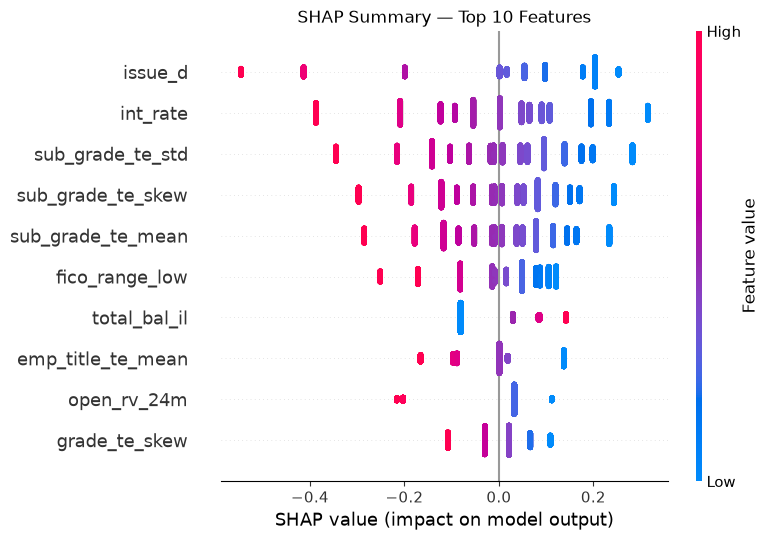

In [45]:
# --- Gain (|coefficient|) ---
gain_df = pd.DataFrame({
    "feature": woe_features,
    "gain": np.abs(final_model.coef_[0]),
}).sort_values("gain", ascending=False)

top10_gain = gain_df.head(10).reset_index(drop=True)
print("Top 10 features by gain (|coefficient|)")
display(top10_gain)

# --- SHAP ---
shap_sample = X_train_woe[woe_features].sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_train_woe)),
    random_state=RANDOM_STATE,
)
explainer = shap.LinearExplainer(final_model, shap_sample, feature_perturbation="interventional")
shap_values = explainer.shap_values(shap_sample)

shap_df = pd.DataFrame({
    "feature": woe_features,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

top10_shap = shap_df.head(10).reset_index(drop=True)
print("Top 10 features by SHAP")
display(top10_shap)

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, show=False, max_display=10)
plt.title("SHAP Summary — Top 10 Features")
plt.tight_layout()
plt.show()

## Top 5 Feature Selection

Rank features by average rank across SHAP and gain, then retrain the final model on the selected top 5.

In [46]:
importance = shap_df.merge(gain_df, on="feature", how="outer")
importance["shap_rank"] = importance["mean_abs_shap"].rank(ascending=False, method="min")
importance["gain_rank"] = importance["gain"].rank(ascending=False, method="min")
importance["avg_rank"] = (importance["shap_rank"] + importance["gain_rank"]) / 2
importance = importance.sort_values("avg_rank")

top5_features = importance.head(5)["feature"].tolist()
print("Top 5 features (SHAP + gain):")
for i, feat in enumerate(top5_features, 1):
    row = importance.loc[importance["feature"] == feat].iloc[0]
    print(
        f"  {i}. {feat} | shap={row['mean_abs_shap']:.4f} "
        f"| gain={row['gain']:.4f} | avg_rank={row['avg_rank']:.1f}"
    )

final_model_top5 = LogisticRegression(
    penalty=best_params["penalty"],
    C=best_params["C"],
    class_weight=best_params["class_weight"],
    solver=solver,
    max_iter=1000,
    random_state=RANDOM_STATE,
)
final_model_top5.fit(X_train_woe[top5_features], y_train)
importance.head(10)

Top 5 features (SHAP + gain):
  1. issue_d | shap=0.1845 | gain=0.9376 | avg_rank=1.0
  2. emp_title_te_mean | shap=0.0684 | gain=0.6129 | avg_rank=5.0
  3. int_rate | shap=0.1435 | gain=0.2607 | avg_rank=5.0
  4. total_bal_il | shap=0.0821 | gain=0.5465 | avg_rank=5.0
  5. sub_grade_te_std | shap=0.1229 | gain=0.2177 | avg_rank=6.0


,feature,mean_abs_shap,gain,shap_rank,gain_rank,avg_rank
14,issue_d,0.184504,0.937620,1.0,1.0,1.0
2,emp_title_te_mean,0.068352,0.612910,8.0,2.0,5.0
13,int_rate,0.143475,0.260694,2.0,8.0,5.0
30,total_bal_il,0.082079,0.546457,7.0,3.0,5.0
25,sub_grade_te_std,0.122866,0.217669,3.0,9.0,6.0
21,open_rv_24m,0.065286,0.458606,9.0,4.0,6.5
6,fico_range_low,0.082819,0.268766,6.0,7.0,6.5
26,title_te_count,0.042752,0.449151,11.0,5.0,8.0
24,sub_grade_te_skew,0.105763,0.187371,4.0,13.0,8.5
19,open_il_24m,0.040341,0.343248,12.0,6.0,9.0


## Model Analysis — KS & AUC

Evaluate the **top-5 feature model** on train, validation, and OOT splits.

Performance — Top 5 Feature Model


,split,auc,ks
0,train,0.6909,0.2769
1,validation,0.7109,0.3126
2,oot,0.7012,0.3046


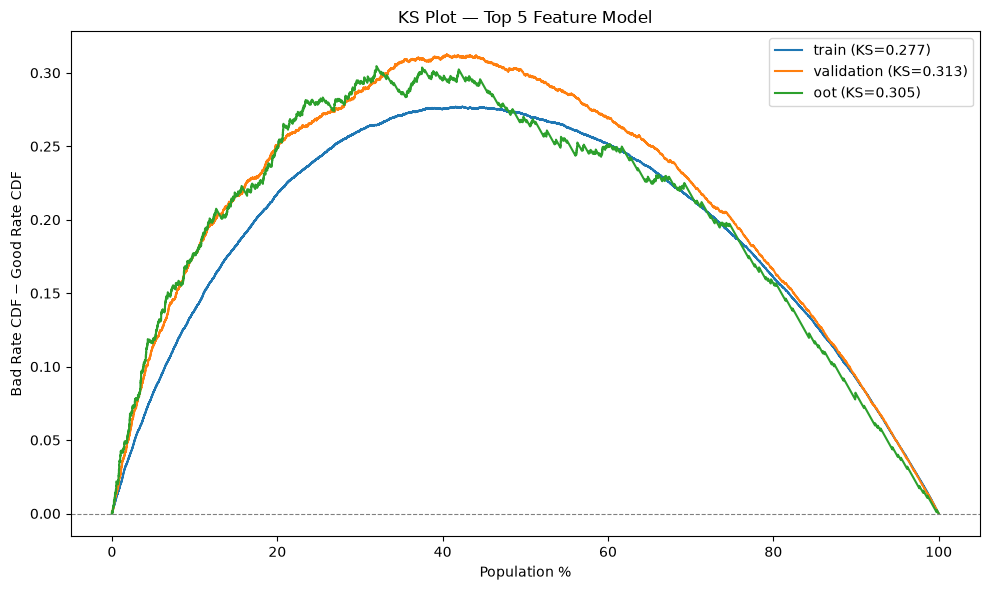

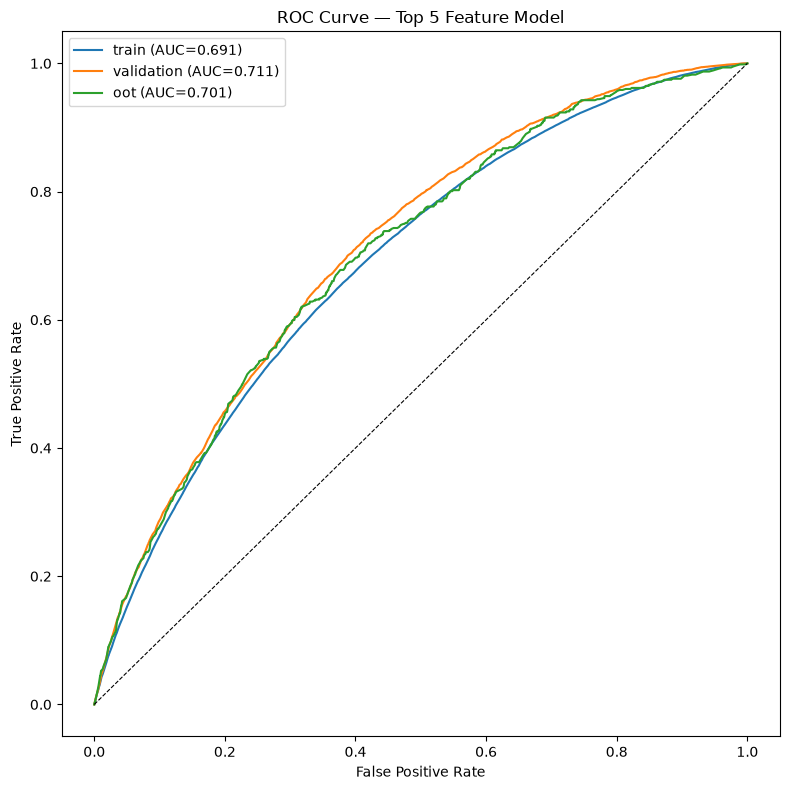

In [47]:
def calc_ks(y_true, y_score):
    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    bad_rate = y_sorted.cumsum() / y_sorted.sum()
    good_rate = (1 - y_sorted).cumsum() / (1 - y_sorted).sum()
    return np.max(np.abs(bad_rate - good_rate))


def ks_curve(y_true, y_score):
    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    pct = np.arange(1, len(y_sorted) + 1) / len(y_sorted) * 100
    bad_rate = y_sorted.cumsum() / y_sorted.sum()
    good_rate = (1 - y_sorted).cumsum() / (1 - y_sorted).sum()
    return pct, bad_rate - good_rate


def evaluate_split(model, X, y, split_name):
    prob = model.predict_proba(X)[:, 1]
    return {
        "split": split_name,
        "auc": roc_auc_score(y, prob),
        "ks": calc_ks(y, prob),
        "prob": prob,
    }


splits = {
    "train": (X_train_woe[top5_features], y_train),
    "validation": (X_test_woe[top5_features], y_test),
    "oot": (X_oot_woe[top5_features], y_oot),
}

results = [evaluate_split(final_model_top5, X, y, name) for name, (X, y) in splits.items()]
metrics_df = pd.DataFrame([{k: v for k, v in r.items() if k != "prob"} for r in results])
print("Performance — Top 5 Feature Model")
display(metrics_df.round(4))

# --- KS Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
for r in results:
    y = splits[r["split"]][1]
    pct, ks_diff = ks_curve(y, r["prob"])
    ax.plot(pct, ks_diff, label=f"{r['split']} (KS={r['ks']:.3f})")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Population %")
ax.set_ylabel("Bad Rate CDF − Good Rate CDF")
ax.set_title("KS Plot — Top 5 Feature Model")
ax.legend()
plt.tight_layout()
plt.show()

# --- ROC / AUC Plot ---
fig, ax = plt.subplots(figsize=(8, 8))
for r in results:
    y = splits[r["split"]][1]
    fpr, tpr, _ = roc_curve(y, r["prob"])
    ax.plot(fpr, tpr, label=f"{r['split']} (AUC={r['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Top 5 Feature Model")
ax.legend()
plt.tight_layout()
plt.show()

## Saving Model Artifacts

In [48]:
import joblib, json, getpass, platform, subprocess, datetime

def _git_commit_hash():
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], stderr=subprocess.DEVNULL).decode().strip()
    except Exception:
        return None

artifact_root = "artifacts"
ts = datetime.datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
artifact_dir = os.path.join(artifact_root, f"credit_scorecard_top5_{ts}")
os.makedirs(artifact_dir, exist_ok=True)

joblib.dump(final_model_top5, os.path.join(artifact_dir, "model_top5.joblib"))
joblib.dump(impute_values, os.path.join(artifact_dir, "impute_values.joblib"))

binners_dir = os.path.join(artifact_dir, "binners")
os.makedirs(binners_dir, exist_ok=True)
for name, b in binners.items():
    try:
        joblib.dump(b, os.path.join(binners_dir, f"{name}.joblib"))
    except Exception:
        with open(os.path.join(binners_dir, f"{name}.txt"), "w", encoding="utf8") as f:
            f.write(repr(b))

with open(os.path.join(artifact_dir, "top5_features.json"), "w", encoding="utf8") as f:
    json.dump(top5_features, f, indent=2)
with open(os.path.join(artifact_dir, "woe_features.json"), "w", encoding="utf8") as f:
    json.dump(woe_features, f, indent=2)

iv_df.to_csv(os.path.join(artifact_dir, "iv_df.csv"), index=False)
gain_df.to_csv(os.path.join(artifact_dir, "gain_df.csv"), index=False)
shap_df.to_csv(os.path.join(artifact_dir, "shap_df.csv"), index=False)
importance.to_csv(os.path.join(artifact_dir, "importance.csv"), index=False)

metrics = {}
for r in results:
    metrics[r["split"]] = {"auc": float(r["auc"]), "gini": float(2 * r["auc"] - 1), "ks": float(r["ks"])}
with open(os.path.join(artifact_dir, "metrics.json"), "w", encoding="utf8") as f:
    json.dump(metrics, f, indent=2)

meta = {
    "model_name": "credit_scorecard_top5",
    "saved_at_utc": ts,
    "user": getpass.getuser(),
    "platform": platform.platform(),
    "python_version": platform.python_version(),
    "git_commit": _git_commit_hash(),
    "num_train_rows": int(len(y_train)),
    "woe_features_count": int(len(woe_features)),
}
meta.update({"experiment_id": study.study_name if hasattr(study, "study_name") else None})
with open(os.path.join(artifact_dir, "metadata.json"), "w", encoding="utf8") as f:
    json.dump(meta, f, indent=2)

print("Artifacts saved to", artifact_dir)

Artifacts saved to artifacts\credit_scorecard_top5_20260816T124014Z
